In [4]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn
import anndata as ad
import numpy as np
import pandas
import random
from scipy import stats
import matplotlib
import matplotlib as mpl
import matplotlib.colors as mcolors
sc._settings.settings._vector_friendly=True
matplotlib.rcParams['pdf.fonttype'] = 42
import os
os.environ['R_HOME'] = '/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/R'
from rpy2.rinterface_lib import openrlib
openrlib.R_HOME = '/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/R'

In [6]:
# use rpy2 to enable R and python in one jupyter notebook
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [7]:
%%R
library(ArchR)

sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [3]:
adata = sc.read_h5ad('./data/scrna.h5ad')

In [4]:
adata_cd4 = adata[adata.obs['celltype_new'].str.startswith('CD4')].copy()
adata_cd8 = adata[adata.obs['celltype_new'].str.startswith('CD8')].copy()

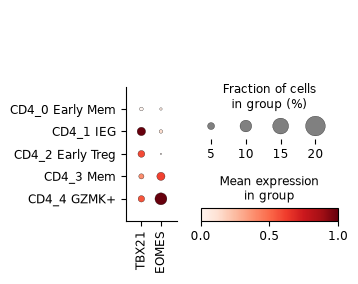

In [7]:
sc.pl.dotplot(adata_cd4, ['TBX21', 'EOMES'], groupby='celltype_new', standard_scale='var')

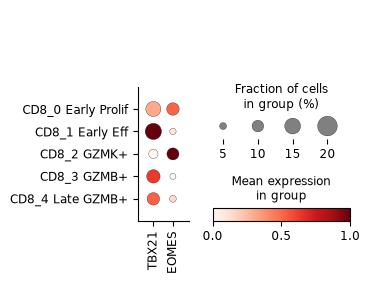

In [8]:
sc.pl.dotplot(adata_cd8, ['TBX21', 'EOMES'], groupby='celltype_new', standard_scale='var')

In [8]:
%%R
scatac <- loadArchRProject('./data/scatac')

Successfully loaded ArchRProject!

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  ._____

In [41]:
%%R 
markersMM_cd4 <- getMarkerFeatures(ArchRProj = scatac[grepl('CD4', scatac$celltype_new),], useMatrix = "MotifMatrix",
            groupBy = "celltype_new", 
            bias = c("TSSEnrichment", "log10(nFrags)"),
            useSeqnames="deviations", 
            testMethod = "wilcoxon")

marker_genes <- unlist(lapply(rowData(markersMM_cd4)$name, function(x) strsplit(x, '_')[[1]][1]))
heatmapMM_cd4 <- markerHeatmap(
      seMarker = markersMM_cd4, #[marker_genes %in% select_genes],
      cutOff = "FDR <= 0.05 & Mean > 0.02",
      transpose = TRUE,
      log2Norm = FALSE, returnMatrix=TRUE,
)

heatmapMM_cd4_sub <- markerHeatmap(
      seMarker = markersMM_cd4[rowData(markersMM_cd4)$name %in% c('RELB_718', 'NFKB1_719', 'RELA_722', 'TCF7_750', 'LEF1_760',
                                                   'BACH2_113', 'FOSB_121', 'FOS_137', 'JUNB_139', 'EOMES_788', 'TBX21_780')], 
      cutOff = "FDR <= 0.05", 
      transpose = TRUE,
      log2Norm = FALSE, returnMatrix=TRUE,
      clusterCols=FALSE
)

sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect

 [1] "NFIL3_133"   "ATF5_136"    "BCL6_187"    "IKZF4_197"   "PRDM16_211" 
 [6] "IKZF1_270"   "RORC_681"    "GMEB2_735"   "NFIB_741"    "NFIA_742"   
[11] "TCF7_750"    "LEF1_760"    "TCF7L2_762"  "TCF7L1_763"  "STAT1_773"  
[16] "GATA1_383"   "GATA3_384"   "GATA4_386"   "GATA6_387"   "HSF2_623"   
[21] "HSF4_624"    "HSF1_627"    "NFKB2_714"   "NFKB1_719"   "NR1D2_841"  
[26] "FOSL2_105"   "BACH2_113"   "JDP2_125"    "JUNB_139"    "GATA5_385"  
[31] "ARID3B_8"    "ARID3C_10"   "MYOD1_48"    "ATOH8_71"    "SNAI2_161"  
[36] "YY1_173"     "CTCF_177"    "CTCFL_198"   "SNAI1_199"   "ZNF143_231" 
[41] "E2F3_313"    "MEOX1_396"   "LHX5_406"    "HOXA13_418"  "NOBOX_420"  
[46] "FOSB_121"    "JUND_124"    "BACH1_130"   "FOS_137"     "FOSL1_142"  
[51] "JUN_143"     "SMARCC1_651" "LHX6_423"    "ATF2_114"   


sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect

 [1] "TCF7_750"  "LEF1_760"  "FOSB_121"  "FOS_137"   "RELB_718"  "RELA_722" 
 [7] "EOMES_788" "BACH2_113" "JUNB_139"  "NFKB1_719" "TBX21_780"


Identified 104 markers!
Identified 11 markers!
In addition: Warning messages:
1: 'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated") 
2: 'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated") 


<S4 Type Object>
attr(,"direction")
[1] "horizontal"
attr(,"layout")
attr(,"layout")$layout_annotation_legend_left_width
[1] 0mm

attr(,"layout")$layout_heatmap_legend_left_width
[1] 0mm

attr(,"layout")$layout_row_title_left_width
[1] 0mm

attr(,"layout")$layout_row_title_right_width
[1] 0mm

attr(,"layout")$layout_heatmap_legend_right_width
[1] 0mm

attr(,"layout")$layout_annotation_legend_right_width
[1] 0mm

attr(,"layout")$layout_annotation_legend_top_height
[1] 0mm

attr(,"layout")$layout_heatmap_legend_top_height
[1] 0mm

attr(,"layout")$layout_column_title_top_height
[1] 0mm

attr(,"layout")$layout_column_title_bottom_height
[1] 0mm

attr(,"layout")$layout_heatmap_legend_bottom_height
[1] 14.0658888888889mm

attr(,"layout")$layout_annotation_legend_bottom_height
[1] 0mm

attr(,"layout")$layout_index
                      layout.pos.row layout.pos.col
heatmaplist                        4              4
heatmap_legend_bottom              6              4

attr(,"layout")$graphic_

Preparing Main Heatmap..


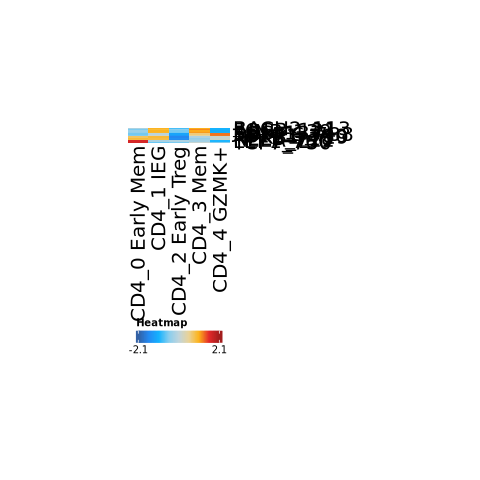

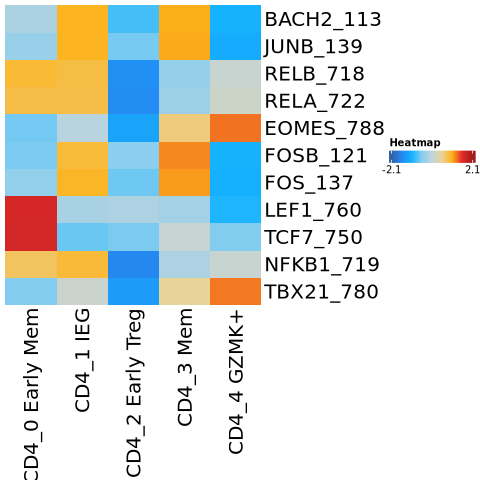

In [47]:
%%R 
p <- ArchR:::.ArchRHeatmap(t(heatmapMM_cd4_sub), labelRows=TRUE, labelCols=TRUE, clusterRows=TRUE, fontSizeRows=20, fontSizeCols=20, 
                      clusterCols=FALSE, scale=FALSE, useRaster=FALSE, limits=c(-2.1, 2.1)) 
print(p, vp = grid::viewport(width = unit(6, "inch"), height = unit(4, "inch")))

In [44]:
%%R 
markersMM_cd8 <- getMarkerFeatures(ArchRProj = scatac[grepl('CD8', scatac$celltype_new),], useMatrix = "MotifMatrix",
            groupBy = "celltype_new", 
            bias = c("TSSEnrichment", "log10(nFrags)"),
            useSeqnames="deviations", 
            testMethod = "wilcoxon")

marker_genes <- unlist(lapply(rowData(markersMM_cd8)$name, function(x) strsplit(x, '_')[[1]][1]))
heatmapMM_cd8 <- markerHeatmap(
      seMarker = markersMM_cd8, #[marker_genes %in% select_genes],
      cutOff = "FDR <= 0.05 & Mean > 0.02",
      transpose = TRUE,
      log2Norm = FALSE, returnMatrix=TRUE,
)

heatmapMM_cd8_sub <- markerHeatmap(
      seMarker = markersMM_cd8[rowData(markersMM_cd8)$name %in% c('RELB_718', 'NFKB1_719', 'RELA_722', 'TCF7_750', 'LEF1_760',
                                                   'BACH2_113', 'FOSB_121', 'FOS_137', 'JUNB_139', 'EOMES_788', 'TBX21_780')], 
      cutOff = "FDR <= 0.05", 
      transpose = TRUE,
      log2Norm = FALSE, returnMatrix=TRUE,
      clusterCols=FALSE
)

sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect

 [1] "PRDM1_163"          "HIVEP1_170"         "ZBTB47_188"        
 [4] "BCL11A_194"         "ZNF683_253"         "ZNF652_278"        
 [7] "TFDP2_308"          "TFDP3_309"          "TFDP1_310"         
[10] "E2F8_314"           "E2F5_315"           "E2F7_316"          
[13] "IRF6_628"           "IRF1_629"           "IRF3_630"          
[16] "ARID3B_8"           "CREB3L3_104"        "CREM_108"          
[19] "CREB3_111"          "CREB1_117"          "ATF1_118"          
[22] "BATF3_120"          "CREB3L4_126"        "ATF7_138"          
[25] "E4F1_234"           "NOBOX_420"          "TLX2_436"          
[28] "HOXB5_445"          "BARHL1_456"         "MNX1_466"          
[31] "MYF6_30"            "DLX5_412"           "TBR1_786"          
[34] "TBX10_791"          "TCF21_39"           "NEUROG3_43"        
[37] "NEUROG2_81"         "ENSG00000187728_92" "TWIST2_101"        
[40] "MGA_103"            "FOSL2_105"          "RORB_865"          
[43] "BACH2_113"          "MAFF_147"           "

sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect

 [1] "RELB_718"  "NFKB1_719" "RELA_722"  "BACH2_113" "FOSB_121"  "FOS_137"  
 [7] "JUNB_139"  "TCF7_750"  "LEF1_760"  "TBX21_780" "EOMES_788"



Identified 110 markers!
Identified 11 markers!
In addition: Warning messages:
1: 'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated") 
2: 'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated") 


<S4 Type Object>
attr(,"direction")
[1] "horizontal"
attr(,"layout")
attr(,"layout")$layout_annotation_legend_left_width
[1] 0mm

attr(,"layout")$layout_heatmap_legend_left_width
[1] 0mm

attr(,"layout")$layout_row_title_left_width
[1] 0mm

attr(,"layout")$layout_row_title_right_width
[1] 0mm

attr(,"layout")$layout_heatmap_legend_right_width
[1] 0mm

attr(,"layout")$layout_annotation_legend_right_width
[1] 0mm

attr(,"layout")$layout_annotation_legend_top_height
[1] 0mm

attr(,"layout")$layout_heatmap_legend_top_height
[1] 0mm

attr(,"layout")$layout_column_title_top_height
[1] 0mm

attr(,"layout")$layout_column_title_bottom_height
[1] 0mm

attr(,"layout")$layout_heatmap_legend_bottom_height
[1] 14.0658888888889mm

attr(,"layout")$layout_annotation_legend_bottom_height
[1] 0mm

attr(,"layout")$layout_index
                      layout.pos.row layout.pos.col
heatmaplist                        4              4
heatmap_legend_bottom              6              4

attr(,"layout")$graphic_

Preparing Main Heatmap..


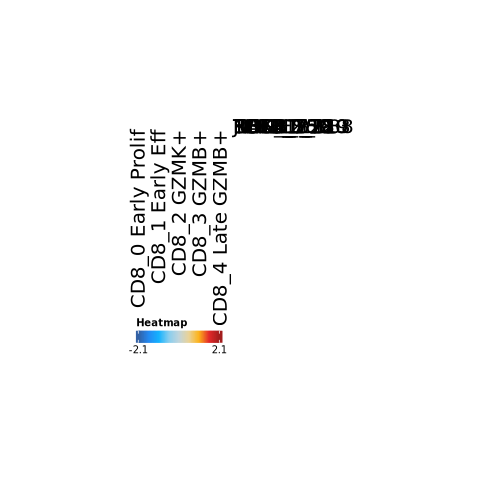

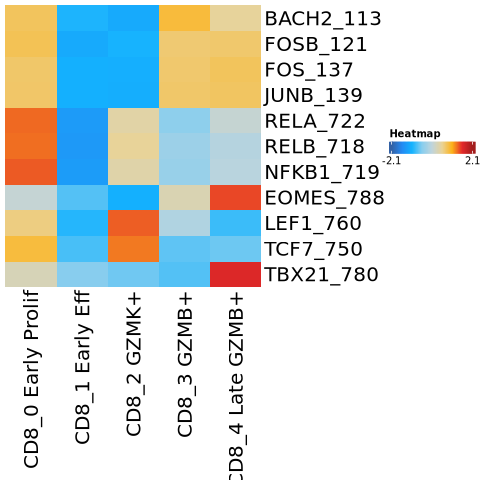

In [46]:
%%R 
p <- ArchR:::.ArchRHeatmap(t(heatmapMM_cd8_sub), labelRows=TRUE, labelCols=TRUE, clusterRows=TRUE, fontSizeRows=20, fontSizeCols=20, 
                      clusterCols=FALSE, scale=FALSE, useRaster=FALSE, limits=c(-2.1, 2.1)) 
print(p, vp = grid::viewport(width = unit(6, "inch"), height = unit(4, "inch")))

In [57]:
%%R
scarlink_filtered_cd4 <- read.table(file='data/scarlink_cd4_tiles.csv', sep='\t', header=TRUE)
scarlink_filtered_cd8 <- read.table(file='data/scarlink_cd8_tiles.csv', sep='\t', header=TRUE)

sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |     gene_id      symbol
         <Rle>         <IRanges>  <Rle> | <character> <character>
  [1]     chr5 55024253-55034570      + |        3003        GZMK
  -------
  seqinfo: 24 sequences from hg38 genome


In addition: Warning messages:
1: `aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ArchR package.
  Please report the issue to the authors.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the ArchR package.
  Please report the issue to the authors.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the ArchR package.
  Please repor

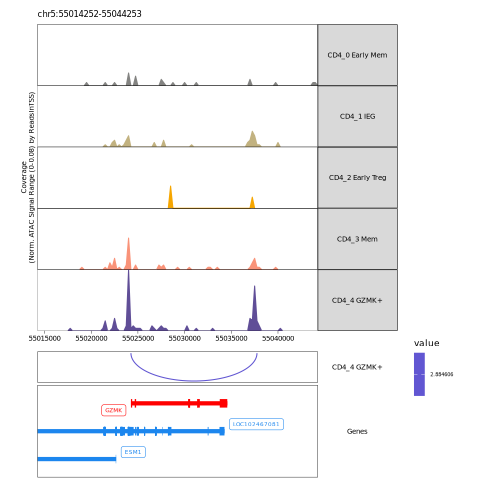

In [55]:
%%R
create_loop_granges <- function(df, gene, tss, cluster){
    df_g <- df[df['gene']==gene & df['celltype_new']==cluster,]
    r1 <- as.numeric((df_g$start + df_g$end)/2)
    r2 <- rep(tss, length(r1))
    df_g$end <- pmax(r1, r2)
    df_g$start <- pmin(r1, r2)
    df_g$value <- df_g$z.score
    #df_g$value <- -log(df_g$FDR,10)
    df_g <- makeGRangesFromDataFrame(df_g, keep.extra.columns=TRUE)
    return(df_g)
}

celltype_colors <- c('CD8_4 Late GZMB+'='#a1caf1',
                     'CD8_3 GZMB+'='#be0032',
                     'CD4_1 IEG'='#c2b280',
                     'CD4_0 Early Mem'='#848482',
                     'CD8_2 GZMK+'='#008856',
                     'CD8_0 Early Prolif'='#e68fac',
                     'CD4_3 Mem'='#f99379',
                     'CD4_4 GZMK+'='#604e97',
                     'CD4_2 Early Treg'='#f6a600',
                     'CD8_1 Early Eff'='#b3446c')

gene <- 'GZMK'
scarlink_filtered_cd4_gene <- scarlink_filtered_cd4[scarlink_filtered_cd4$gene==gene,]
features_list <- GRangesList(#"CD4_0 Early Mem"=create_feature_granges(scarlink_filtered_cd4_gene, gene, 'CD4_0 Early Mem', 'celltype_new_3'),
                         #"CD4_1 IEG"=create_feature_granges(scarlink_filtered_cd4_gene, gene, 'CD4_1 IEG', 'celltype_new_3'),
                         #"CD4_2 Early Treg"=create_feature_granges(scarlink_filtered_cd4_gene, gene, 'CD4_2 Early Treg', 'celltype_new_3'),
                         #"CD4_3 Mem"=create_feature_granges(scarlink_filtered_cd4_gene, gene, 'CD4_3 Mem', 'celltype_new_3'),
                         "CD4_4 GZMK+"=create_loop_granges(scarlink_filtered_cd4_gene, gene, 55024253, 'CD4_4 GZMK+'))

p <- plotBrowserTrack(
  ArchRProj = scatac[grepl('CD4', scatac$celltype_new),],
  geneSymbol = c(gene),
  groupBy = "celltype_new", pal=celltype_colors, #highlightFill=celltype_colors,
  upstream=10000, downstream=20000,
  plotSummary = c("bulkTrack", "loopTrack", 
                  "geneTrack"),
  sizes = c(10, 1, 3),
  loops = features_list
) 

options(repr.plot.width=5, repr.plot.height=6)
grid::grid.newpage()
grid::grid.draw(p$GZMK)

In [60]:
%%R

get_granges_from_string <- function(h){
    h <- colnames(h)
    df <- makeGRangesFromDataFrame(data.frame(chr=unlist(as.vector(lapply(h, function(x) strsplit(x, ":")[[1]][1]))),
                 start=unlist(as.vector(lapply(h, function(x) as.numeric(strsplit(strsplit(x, ":")[[1]][2], '-')[[1]][1])))),
                 end=unlist(as.vector(lapply(h, function(x) strsplit(x, "-")[[1]][2])))))
    return(df)
}

get_gene_names_from_scarlink <- function(h, scarlink){
    #print(h)
    peaks_h <- makeGRangesFromDataFrame(get_granges_from_string(h))
    peaks_scarlink <- makeGRangesFromDataFrame(scarlink, keep.extra.columns=TRUE)
    overlaps <- findOverlaps(peaks_h, peaks_scarlink)
    peaks.overlapping <- peaks_h[queryHits(overlaps)]
    scarlink.corresponding <- peaks_scarlink[subjectHits(overlaps)]
    mcols(peaks.overlapping)$gene <- mcols(scarlink.corresponding)$gene
    gene_names <- rep('', length(peaks_h))
    gene_names[queryHits(overlaps)] <- mcols(scarlink.corresponding)$gene
    return(gene_names)
}                                             

In [61]:
%%R
markerPeaks_cd4 <- readRDS('./data/markerPeaks_cd4_archr_binom.rds')
markerPeaks_cd8 <- readRDS('./data/markerPeaks_cd8_archr_binom.rds')

h_cd4 <- plotMarkerHeatmap(
  seMarker = markerPeaks_cd4, 
  cutOff = "FDR <= 0.1 & Log2FC >= 1", #0.5",
  transpose = TRUE, returnMatrix=TRUE
)

h_cd8 <- plotMarkerHeatmap(
  seMarker = markerPeaks_cd8, 
  cutOff = "FDR <= 0.1 & Log2FC >= 1", #0.5",
  transpose = TRUE, returnMatrix=TRUE
)

h_cd4_new <- h_cd4
h_cd8_new <- h_cd8
gene_names_cd4 <- get_gene_names_from_scarlink(h_cd4_new, scarlink_filtered_cd4)
gene_names_cd8 <- get_gene_names_from_scarlink(h_cd8_new, scarlink_filtered_cd8)
colnames(h_cd4_new) <- gene_names_cd4
colnames(h_cd8_new) <- gene_names_cd8

sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect

 [1] "chr1:817040-817540"     "chr1:923601-924101"     "chr1:960326-960826"    
 [4] "chr1:1001781-1002281"   "chr1:1012731-1013231"   "chr1:1099122-1099622"  
 [7] "chr1:1144034-1144534"   "chr1:1209563-1210063"   "chr1:1213938-1214438"  
[10] "chr1:1677639-1678139"   "chr1:2019038-2019538"   "chr1:2212369-2212869"  
[13] "chr1:2539267-2539767"   "chr1:2894311-2894811"   "chr1:2921973-2922473"  
[16] "chr1:857882-858382"     "chr1:903643-904143"     "chr1:924802-925302"    
[19] "chr1:1020597-1021097"   "chr1:1199940-1200440"   "chr1:1216322-1216822"  
[22] "chr1:1219226-1219726"   "chr1:1284756-1285256"   "chr1:2230861-2231361"  
[25] "chr1:3695581-3696081"   "chr1:5481823-5482323"   "chr1:5993610-5994110"  
[28] "chr1:6248968-6249468"   "chr1:6446831-6447331"   "chr1:6463553-6464053"  
[31] "chr1:2050055-2050555"   "chr1:2195119-2195619"   "chr1:2584014-2584514"  
[34] "chr1:3922211-3922711"   "chr1:6489809-6490309"   "chr1:7930915-7931415"  
[37] "chr1:9413369-9413869"   "chr1:9799

sh: create_passwd: line 1: syntax error: unexpected end of file
sh: error importing function definition for `create_passwd'
sh: which: line 1: syntax error: unexpected end of file
sh: error importing function definition for `which'
sh: module: line 1: syntax error: unexpected end of file
sh: error importing function definition for `module'
sh: wait_until_port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `wait_until_port_used'
sh: find_port: line 1: syntax error: unexpected end of file
sh: error importing function definition for `find_port'
sh: port_used: line 1: syntax error: unexpected end of file
sh: error importing function definition for `port_used'
sh: random_number: line 1: syntax error: unexpected end of file
sh: error importing function definition for `random_number'
sh: source_helpers: line 1: syntax error: unexpected end of file
sh: error importing function definition for `source_helpers'
sh: ml: line 1: syntax error: unexpect

 [1] "chr1:898253-898753"   "chr1:910211-910711"   "chr1:912815-913315"  
 [4] "chr1:968882-969382"   "chr1:978332-978832"   "chr1:997763-998263"  
 [7] "chr1:1044425-1044925" "chr1:1074068-1074568" "chr1:1206354-1206854"
[10] "chr1:1213421-1213921" "chr1:1239894-1240394" "chr1:1240455-1240955"
[13] "chr1:1244773-1245273" "chr1:1282043-1282543" "chr1:1340947-1341447"
[16] "chr1:844417-844917"   "chr1:1063416-1063916" "chr1:1122993-1123493"
[19] "chr1:1221856-1222356" "chr1:1231187-1231687" "chr1:1291785-1292285"
[22] "chr1:1311906-1312406" "chr1:1353484-1353984" "chr1:1505391-1505891"
[25] "chr1:1625461-1625961" "chr1:1627347-1627847" "chr1:1747007-1747507"
[28] "chr1:1889724-1890224" "chr1:2226124-2226624" "chr1:2311425-2311925"
[31] "chr1:941792-942292"   "chr1:1032376-1032876" "chr1:1036645-1037145"
[34] "chr1:1141171-1141671" "chr1:1144034-1144534" "chr1:1173593-1174093"
[37] "chr1:1209563-1210063" "chr1:1250835-1251335" "chr1:1419942-1420442"
[40] "chr1:1427184-1427684" "chr1:1434

Identified 16873 markers!
Identified 21779 markers!


Scaling Matrix..
Preparing Main Heatmap..
'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.


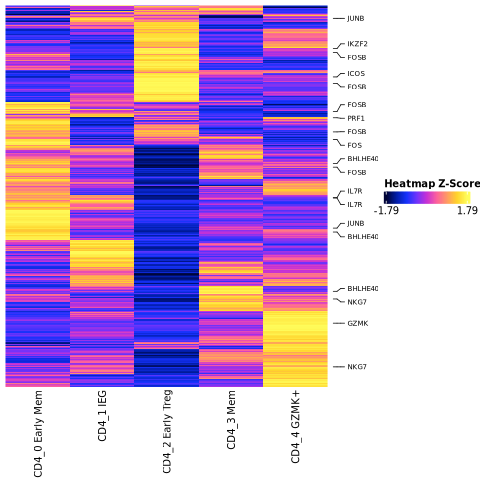

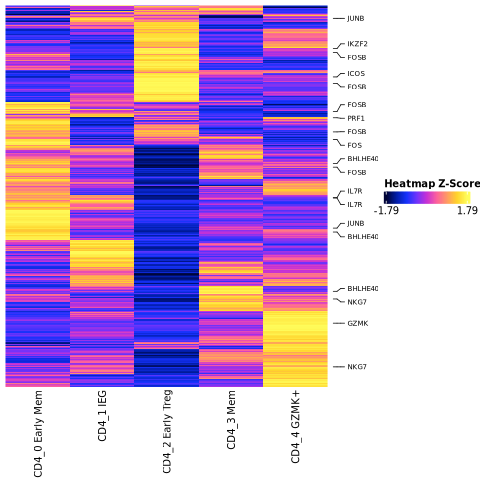

In [67]:
%%R
select_cols_cd4 <- c('JUNB', 'IKZF2', 'FOSB', 'ICOS', 'PRF1', 'FOS', 'BHLHE40', 'IL7R', 'NKG7', 'GZMK')

options(repr.plot.width = 5, repr.plot.height = 5)
ht1 <- ArchR:::.ArchRHeatmap(t(h_cd4_new), labelRows=TRUE, labelCols=TRUE, clusterRows=TRUE,
                      clusterCols=FALSE, scale=TRUE, useRaster=TRUE, draw=FALSE,  
                             color = paletteContinuous(set = "horizonExtra", n = 100)) 
ha_row <- rowAnnotation(link = anno_mark(at = c(1:length(h_cd4_new))[colnames(h_cd4_new) %in% select_cols_cd4],
                        labels = colnames(h_cd4_new)[colnames(h_cd4_new) %in% select_cols_cd4],
                        labels_gp = gpar(fontsize = 7), padding = unit(3, "mm")))
p <- draw(ht1 + ha_row)
p

Scaling Matrix..
Preparing Main Heatmap..
'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.


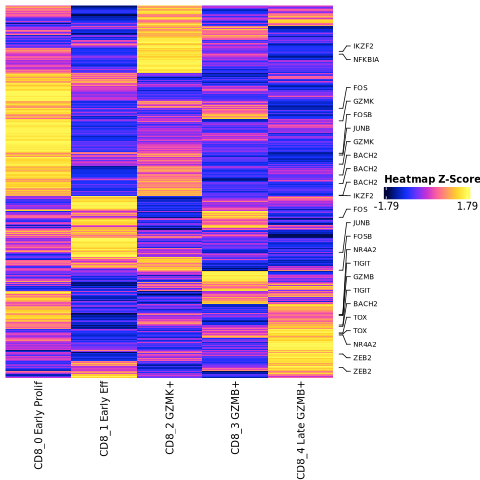

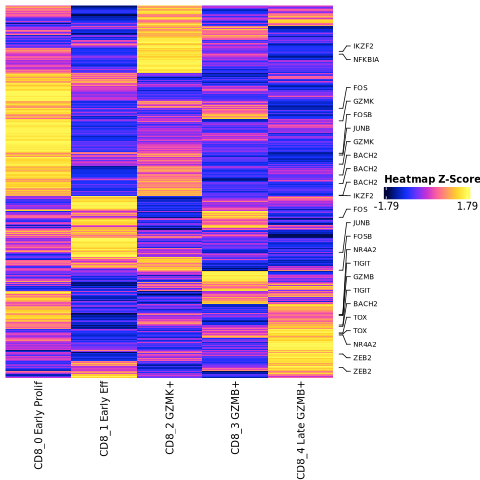

In [68]:
%%R
select_cols_cd8 <- c('IKZF2', 'NFKBIA', 'FOS', 'GZMK', 'FOSB', 'JUNB', 'BACH2', 'NR4A2', 'TIGIT', 'GZMB', 'TOX','ZEB2')

options(repr.plot.width = 5, repr.plot.height = 5)
ht1 <- ArchR:::.ArchRHeatmap(t(h_cd8_new), labelRows=TRUE, labelCols=TRUE, clusterRows=TRUE,
                      clusterCols=FALSE, scale=TRUE, useRaster=TRUE, draw=FALSE,  
                             color = paletteContinuous(set = "horizonExtra", n = 100)) 
ha_row <- rowAnnotation(link = anno_mark(at = c(1:length(h_cd8_new))[colnames(h_cd8_new) %in% select_cols_cd8],
                        labels = colnames(h_cd8_new)[colnames(h_cd8_new) %in% select_cols_cd8],
                        labels_gp = gpar(fontsize = 7), padding = unit(3, "mm")))
p <- draw(ht1 + ha_row)
p

In [72]:
cd4_rest_vs_cd4_4 = pandas.read_csv('data/ame_out_cd4_rest_vs_cd4_4.csv', sep='\t')
cd4_4_vs_cd4_rest = pandas.read_csv('data/ame_out_cd4_4_vs_cd4_rest.csv', sep='\t')

In [73]:
def plot_bars_waterfall(df1, df2, t, ax=None):
    pv = 'evalue' # 'adj.pvalue'
    df = df1
    df['log10_padj'] = -np.log10(df[pv])
    df = df[~df['motif_alt_id'].str.contains('musculus')]
    df = df[~df['motif_alt_id'].str.contains('Drosophila')]
    df = df[~df['motif_alt_id'].str.contains('elegans')]
    df = df[~df['motif_alt_id'].str.contains('_')]
    df['color'] = 'grey'
    df.loc[(df['rank'] < 10) & (df[pv] < 0.05), 'color'] = 'blue'
    df = df[df['color']=='blue']
    df['log10_padj'] = -df['log10_padj'] 
    df1 = df
    
    df = df2
    df['log10_padj'] = -np.log10(df[pv])
    df = df[~df['motif_alt_id'].str.contains('musculus')]
    df = df[~df['motif_alt_id'].str.contains('Drosophila')]
    df = df[~df['motif_alt_id'].str.contains('elegans')]
    df = df[~df['motif_alt_id'].str.contains('_')]
    df['color'] = 'grey'
    df.loc[(df['rank'] < 10) & (df[pv] < 0.05), 'color'] = 'blue'
    df = df[df['color']=='blue']
    df2 = df
    df = pandas.concat([df1, df2])
    df = df.sort_values(by='log10_padj', ascending=False)
    #print(df)
    #pal = {'grey': 'grey', 'blue': 'blue'}
    if ax is None: ax = plt.gca()

    v = np.abs(df['log10_padj'].values).max()
    norm = plt.Normalize(vmin=-v, vmax=v)
    cmap = seaborn.color_palette("coolwarm", as_cmap=True)
    colors = [cmap(norm(x)) for x in df['log10_padj'].values]    
    seaborn.barplot(data=df, y='motif_alt_id', x='log10_padj', ax=ax, palette=colors)
    #ax.tick_params(axis='x', labelrotation=90)
    ax.set_title(t)
    (y1, y2) = ax.get_xlim()
    y = max(np.abs(y1), np.abs(y2))
    ax.set_xlim((-y, y))

/tmp/ipykernel_3604573/1806083505.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  seaborn.barplot(data=df, y='motif_alt_id', x='log10_padj', ax=ax, palette=colors)


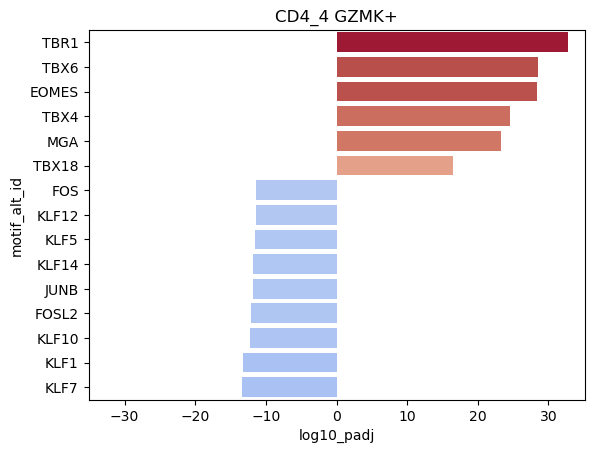

In [74]:
plot_bars_waterfall(cd4_rest_vs_cd4_4, cd4_4_vs_cd4_rest, 'CD4_4 GZMK+')